# 🍌 Klasifikasi Kualitas Buah Pisang
**Algoritma:** K-Nearest Neighbors (KNN) + PCA  
**Fitur:** Color Histogram, Color Statistics, LBP Texture, Gradient, Shape  

Notebook ini menggunakan pipeline yang **identik** dengan aplikasi final (`app.py` & `train.py`) dan menyajikan visualisasi data untuk keperluan laporan.

## 1. Import Library

In [2]:
import os
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline
sns.set_theme(style='whitegrid', palette='pastel')

# Warna per kelas (konsisten dengan aplikasi)
CLASS_COLORS = {'mentah': '#16a34a', 'matang': '#f59e0b', 'busuk': '#9a3412'}
print('Library berhasil dimuat!')

Library berhasil dimuat!


## 2. Konfigurasi Dataset

In [3]:
DATASET_PATH = '../data'
CLASSES      = ['busuk', 'matang', 'mentah']
IMG_SIZE     = 128

# Hitung jumlah gambar per kelas
count_per_class = {}
for cls in CLASSES:
    folder = os.path.join(DATASET_PATH, cls)
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
    count_per_class[cls] = len(files)
    print(f'  {cls:10s}: {len(files)} gambar')

print(f'\nTotal gambar: {sum(count_per_class.values())}')

  busuk     : 203 gambar
  matang    : 186 gambar
  mentah    : 131 gambar

Total gambar: 520


## 3. Visualisasi Distribusi Dataset

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = [CLASS_COLORS[c] for c in CLASSES]
bars = axes[0].bar(CLASSES, [count_per_class[c] for c in CLASSES], color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, [count_per_class[c] for c in CLASSES]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
                 ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Distribusi Dataset per Kelas', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].set_ylim(0, max(count_per_class.values()) * 1.15)

# Pie chart
axes[1].pie(
    [count_per_class[c] for c in CLASSES],
    labels=CLASSES,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporsi Kelas Dataset', fontsize=14, fontweight='bold')

plt.suptitle('Distribusi Dataset Kualitas Pisang', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Visualisasi Sampel Gambar per Kelas

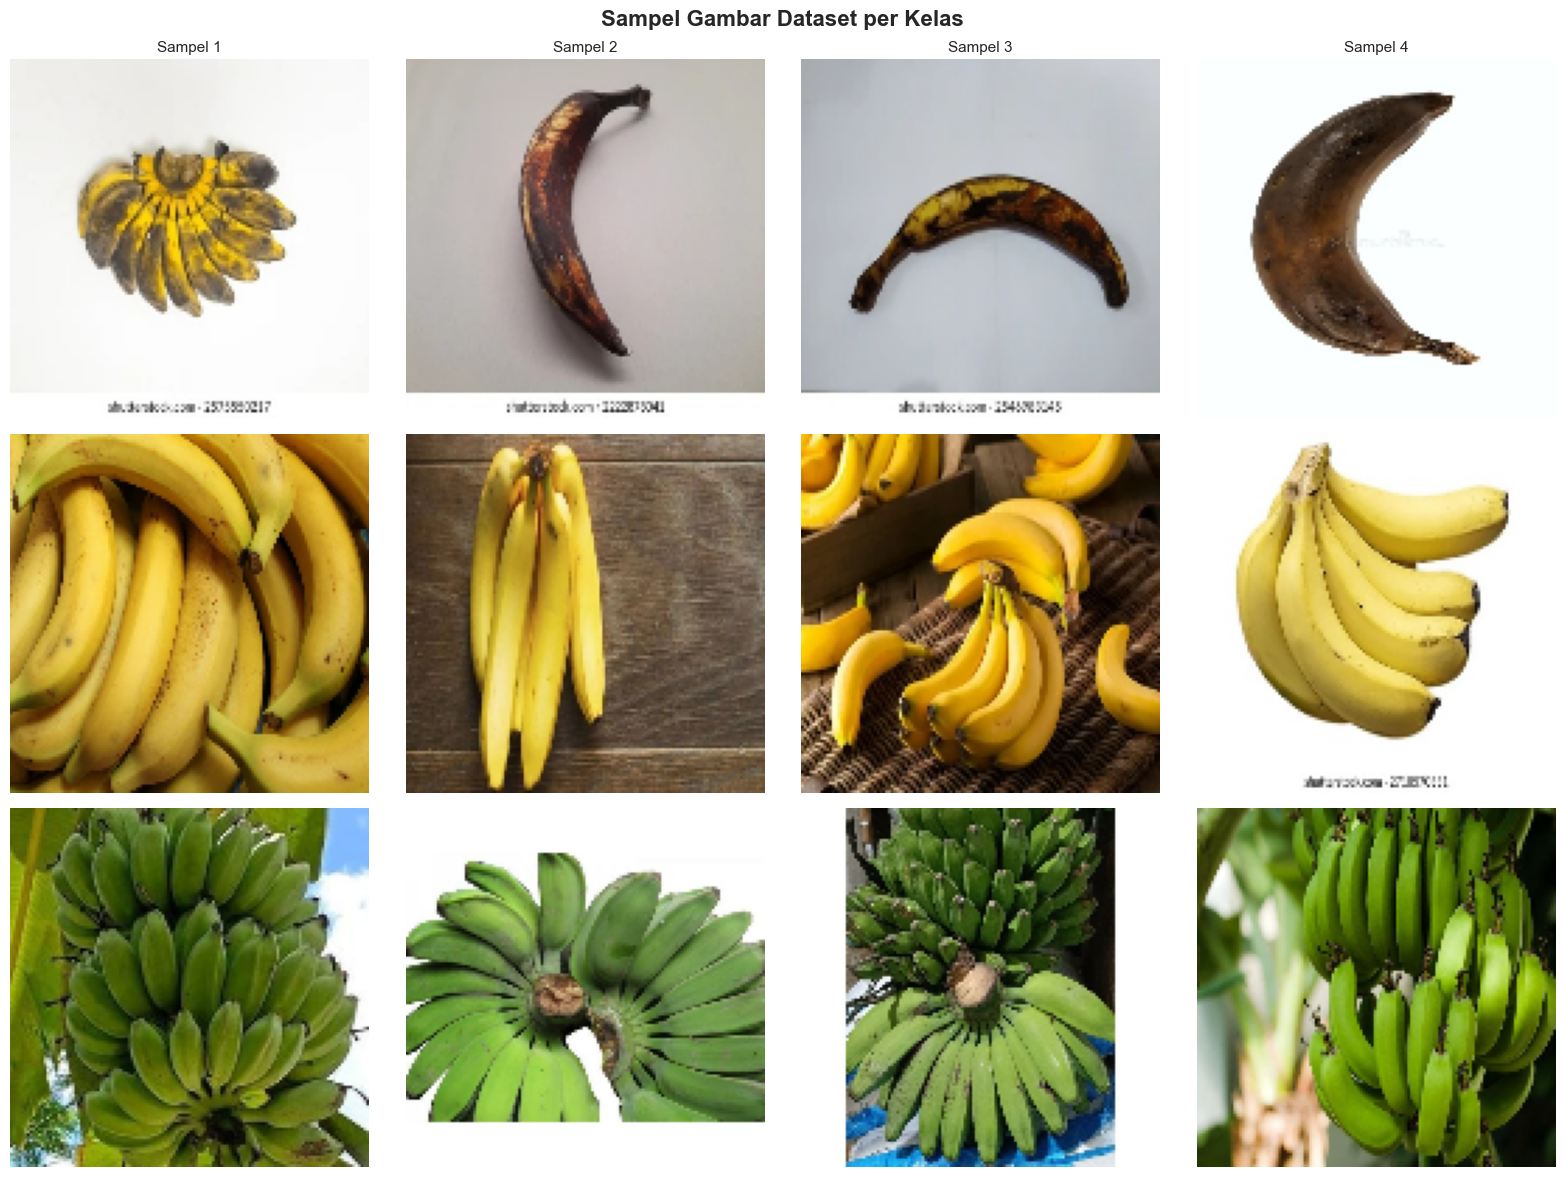

In [4]:
N_SAMPLES = 4
fig, axes = plt.subplots(3, N_SAMPLES, figsize=(16, 12))

for row, cls in enumerate(CLASSES):
    folder = os.path.join(DATASET_PATH, cls)
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))][:N_SAMPLES]
    for col, fname in enumerate(files):
        img = cv2.imread(os.path.join(folder, fname))
        img_rgb = cv2.cvtColor(cv2.resize(img, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img_rgb)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'Sampel {col+1}', fontsize=11)
        if col == 0:
            axes[row, col].set_ylabel(cls.upper(), fontsize=13, fontweight='bold',
                                       color=CLASS_COLORS[cls], rotation=0, labelpad=60, va='center')

plt.suptitle('Sampel Gambar Dataset per Kelas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Fungsi Ekstraksi Fitur
Fungsi-fungsi berikut **identik** dengan yang ada di `app.py` dan `train.py`.

In [5]:
def create_banana_mask(hsv):
    """Masking background menggunakan deteksi warna pisang + morfologi."""
    mask_yellow_brown = cv2.inRange(hsv, (0, 20, 30), (40, 255, 255))
    mask_green = cv2.inRange(hsv, (35, 30, 30), (90, 255, 255))
    mask = cv2.bitwise_or(mask_yellow_brown, mask_green)
    if np.count_nonzero(mask) < IMG_SIZE * IMG_SIZE * 0.05:
        mask = cv2.inRange(hsv, (0, 10, 20), (180, 255, 255))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=1)
    return mask

def extract_color_features(hsv, mask):
    hist_h = cv2.calcHist([hsv], [0], mask, [32], [0, 180])
    hist_s = cv2.calcHist([hsv], [1], mask, [32], [0, 256])
    cv2.normalize(hist_h, hist_h)
    cv2.normalize(hist_s, hist_s)
    stats = []
    for ch in range(3):
        channel = hsv[:, :, ch]
        pixels = channel[mask > 0]
        if len(pixels) > 0:
            stats += [np.mean(pixels), np.std(pixels), np.percentile(pixels, 25), np.percentile(pixels, 75)]
        else:
            stats += [0, 0, 0, 0]
    return np.concatenate([hist_h.flatten(), hist_s.flatten(), stats])

def extract_lbp_features(gray, mask):
    radius = 2
    n_points = 8 * radius
    lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
    lbp_pixels = lbp[mask > 0]
    if len(lbp_pixels) == 0:
        return np.zeros(n_points + 2)
    hist, _ = np.histogram(lbp_pixels, bins=n_points + 2, range=(0, n_points + 2), density=True)
    return hist

def extract_gradient_features(gray, mask):
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = cv2.magnitude(sobelx, sobely)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    lap_abs = np.abs(laplacian)
    pixels_mag = magnitude[mask > 0]
    pixels_lap = lap_abs[mask > 0]
    if len(pixels_mag) == 0:
        return np.zeros(6)
    return np.array([
        np.mean(pixels_mag), np.std(pixels_mag), np.percentile(pixels_mag, 75),
        np.mean(pixels_lap), np.std(pixels_lap), np.var(pixels_lap)
    ])

def extract_shape_features(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros(5)
    c = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c, True)
    hull = cv2.convexHull(c)
    hull_area = cv2.contourArea(hull)
    x, y, w, h = cv2.boundingRect(c)
    extent = area / (w * h) if w * h > 0 else 0
    solidity = area / hull_area if hull_area > 0 else 0
    aspect_ratio = float(w) / h if h > 0 else 0
    return np.array([area, perimeter, extent, solidity, aspect_ratio])

def extract_all_features(image):
    """Master feature extraction - identik dengan app.py."""
    image_resized = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    hsv  = cv2.cvtColor(image_resized, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(image_resized, cv2.COLOR_BGR2GRAY)
    mask = create_banana_mask(hsv)
    color_feats    = extract_color_features(hsv, mask)
    lbp_feats      = extract_lbp_features(gray, mask)
    gradient_feats = extract_gradient_features(gray, mask)
    shape_feats    = extract_shape_features(mask)
    return np.nan_to_num(np.concatenate([color_feats, lbp_feats, gradient_feats, shape_feats]))

def augment_image(image):
    augmented = [image, cv2.flip(image, 1)]
    augmented.append(np.clip(image.astype(np.int32) + 30, 0, 255).astype(np.uint8))
    augmented.append(np.clip(image.astype(np.int32) - 30, 0, 255).astype(np.uint8))
    h, w = image.shape[:2]
    for angle in [-15, 15]:
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        augmented.append(cv2.warpAffine(image, M, (w, h)))
    return augmented

print('Fungsi ekstraksi fitur berhasil didefinisikan!')

Fungsi ekstraksi fitur berhasil didefinisikan!


## 6. Visualisasi Proses Masking Objek Pisang

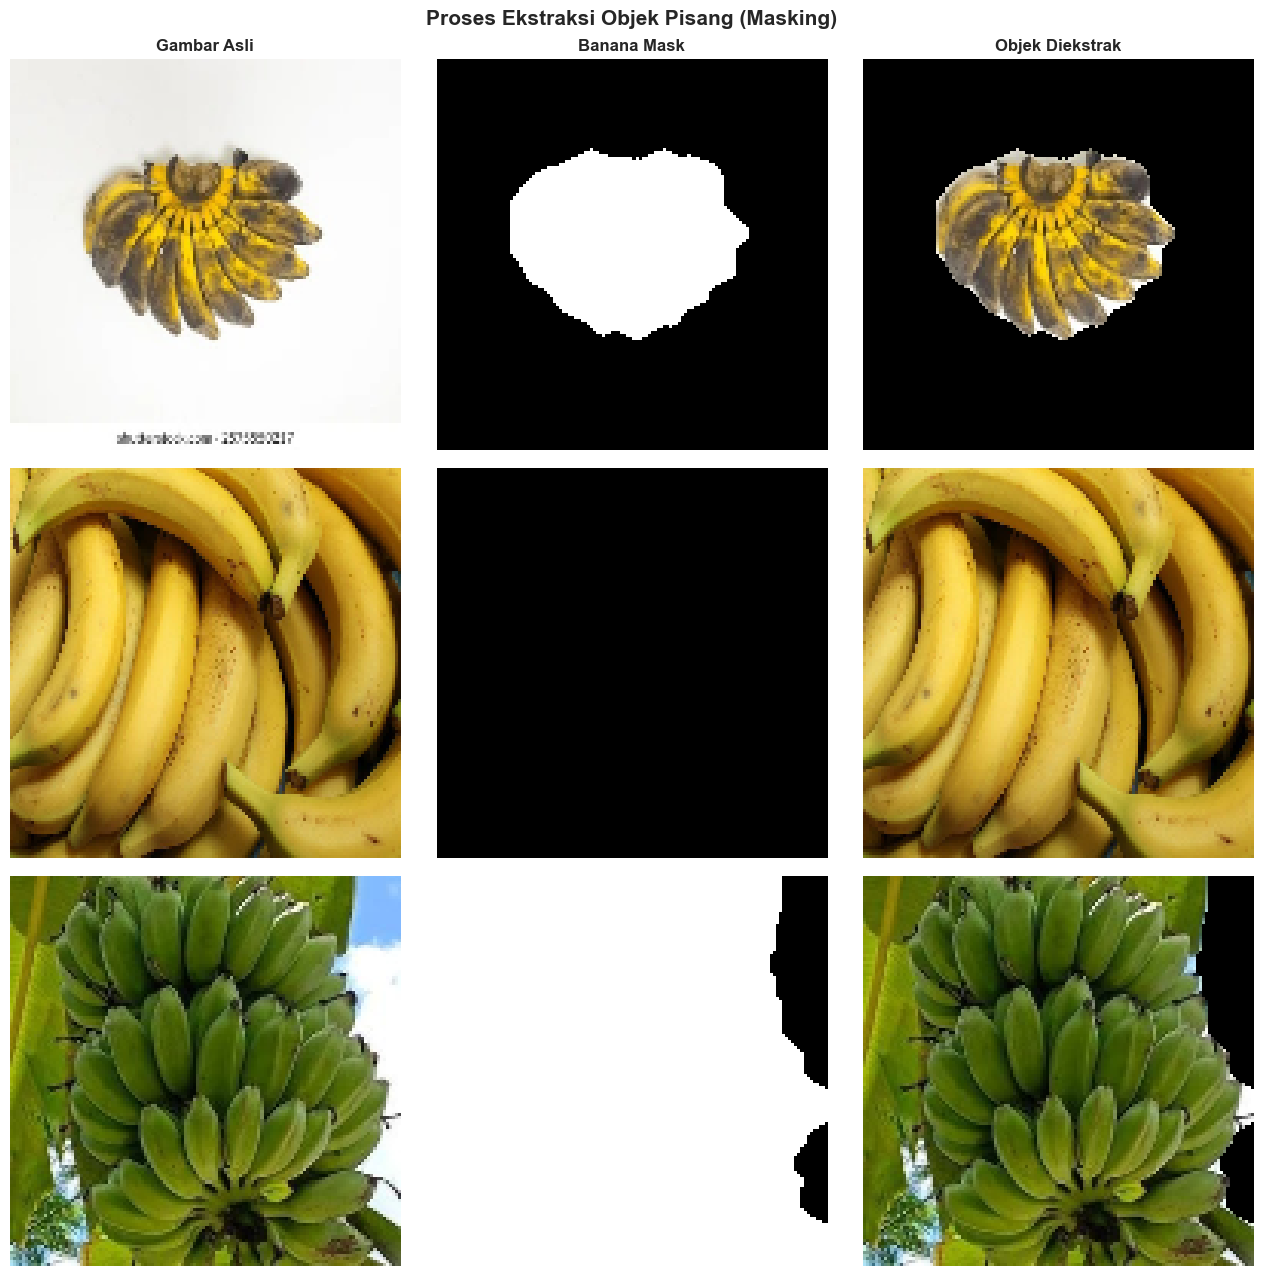

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(13, 13))
titles = ['Gambar Asli', 'Banana Mask', 'Objek Diekstrak']

for row, cls in enumerate(CLASSES):
    folder = os.path.join(DATASET_PATH, cls)
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
    img = cv2.imread(os.path.join(folder, files[0]))
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
    mask = create_banana_mask(hsv)
    img_masked = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

    for col, (data, cmap) in enumerate([(img_rgb, None), (mask, 'gray'), (img_masked, None)]):
        axes[row, col].imshow(data, cmap=cmap)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(titles[col], fontsize=12, fontweight='bold')
        if col == 0:
            axes[row, col].set_ylabel(cls.upper(), fontsize=12, fontweight='bold',
                                       color=CLASS_COLORS[cls], rotation=0, labelpad=55, va='center')

plt.suptitle('Proses Ekstraksi Objek Pisang (Masking)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Ekstraksi Fitur dari Seluruh Dataset

In [7]:
X, y, y_ori = [], [], []

print('Mengekstrak fitur dari seluruh dataset...')
for label in CLASSES:
    folder = os.path.join(DATASET_PATH, label)
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
    print(f'  [{label}] {len(files)} gambar asli', end='')
    for fname in files:
        y_ori.append(label)
        img = cv2.imread(os.path.join(folder, fname))
        if img is None: continue
        for aug_img in augment_image(img):
            X.append(extract_all_features(aug_img))
            y.append(label)
    aug_count = sum(1 for lbl in y if lbl == label)
    print(f' -> {aug_count} total (dengan augmentasi)')

X = np.array(X)
y = np.array(y)
print(f'\nTotal sampel (dengan augmentasi): {len(X)}')
print(f'Dimensi fitur per gambar        : {X.shape[1]}')

Mengekstrak fitur dari seluruh dataset...
  [busuk] 203 gambar asli -> 1218 total (dengan augmentasi)
  [matang] 186 gambar asli -> 1116 total (dengan augmentasi)
  [mentah] 131 gambar asli -> 786 total (dengan augmentasi)

Total sampel (dengan augmentasi): 3120
Dimensi fitur per gambar        : 105


## 8. Distribusi Dataset Sebelum & Sesudah Augmentasi

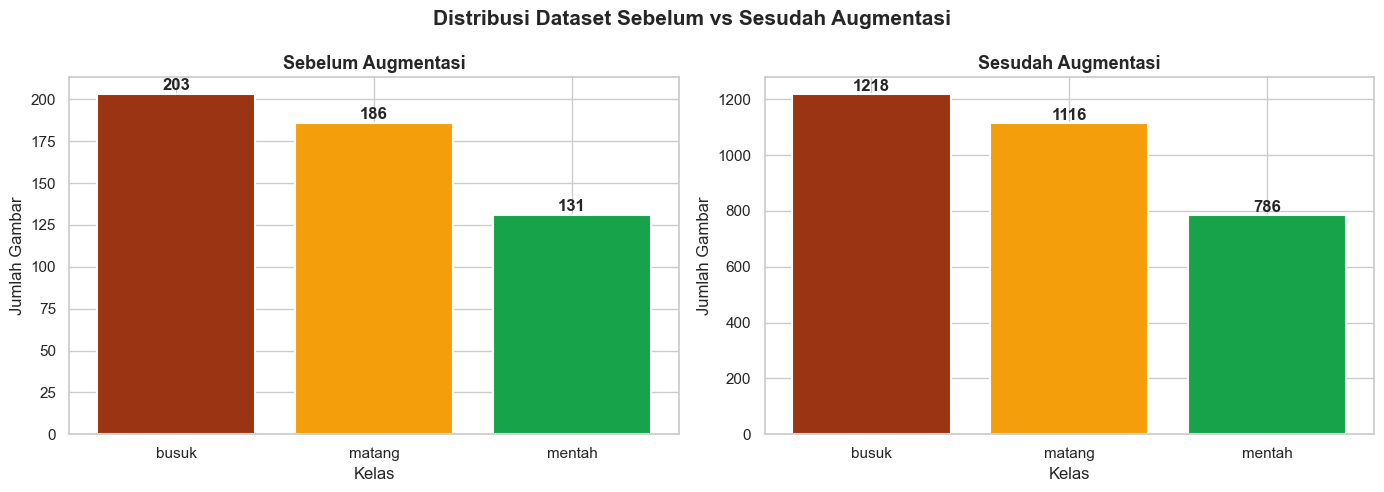

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = [CLASS_COLORS[c] for c in CLASSES]

ori_counts = [y_ori.count(c) for c in CLASSES]
aug_counts = [int(np.sum(y == c)) for c in CLASSES]

b1 = ax1.bar(CLASSES, ori_counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(b1, ori_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(v),
             ha='center', va='bottom', fontweight='bold')
ax1.set_title('Sebelum Augmentasi', fontsize=13, fontweight='bold')
ax1.set_xlabel('Kelas')
ax1.set_ylabel('Jumlah Gambar')

b2 = ax2.bar(CLASSES, aug_counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(b2, aug_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(v),
             ha='center', va='bottom', fontweight='bold')
ax2.set_title('Sesudah Augmentasi', fontsize=13, fontweight='bold')
ax2.set_xlabel('Kelas')
ax2.set_ylabel('Jumlah Gambar')

plt.suptitle('Distribusi Dataset Sebelum vs Sesudah Augmentasi', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Preprocessing: Standardisasi & PCA

In [9]:
encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_p = pca.fit_transform(X_train_s)
X_test_p  = pca.transform(X_test_s)

print(f'Kelas              : {list(encoder.classes_)}')
print(f'Data latih         : {len(X_train)} sampel')
print(f'Data uji           : {len(X_test)} sampel')
print(f'Fitur sebelum PCA  : {X_train_s.shape[1]}')
print(f'Fitur sesudah PCA (95% variance): {X_train_p.shape[1]}')

Kelas              : [np.str_('busuk'), np.str_('matang'), np.str_('mentah')]
Data latih         : 2496 sampel
Data uji           : 624 sampel
Fitur sebelum PCA  : 105
Fitur sesudah PCA (95% variance): 41


## 10. Visualisasi PCA – Explained Variance

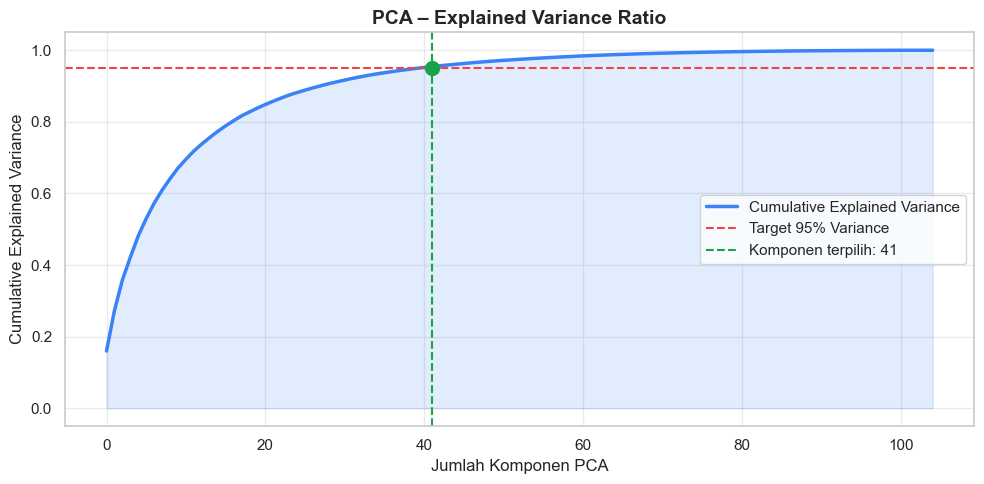

In [10]:
pca_full = PCA(random_state=42).fit(X_train_s)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_95 = X_train_p.shape[1]

plt.figure(figsize=(10, 5))
plt.plot(cumulative_var, linewidth=2.5, color='#3b82f6', label='Cumulative Explained Variance')
plt.fill_between(range(len(cumulative_var)), cumulative_var, alpha=0.15, color='#3b82f6')
plt.axhline(y=0.95, color='#ef4444', linestyle='--', linewidth=1.5, label='Target 95% Variance')
plt.axvline(x=n_comp_95, color='#16a34a', linestyle='--', linewidth=1.5, label=f'Komponen terpilih: {n_comp_95}')
plt.scatter([n_comp_95], [0.95], color='#16a34a', s=100, zorder=5)
plt.xlabel('Jumlah Komponen PCA', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('PCA – Explained Variance Ratio', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 11. Training Model – KNN + GridSearchCV

In [11]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train_p, y_train)

best_knn = grid.best_estimator_
print(f'\nParameter terbaik  : {grid.best_params_}')
print(f'Akurasi Cross-Val  : {grid.best_score_*100:.2f}%')

Fitting 5 folds for each of 28 candidates, totalling 140 fits

Parameter terbaik  : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Akurasi Cross-Val  : 98.68%


## 12. Evaluasi Model

In [12]:
y_pred = best_knn.predict(X_test_p)
acc = accuracy_score(y_test, y_pred)

print(f'Akurasi Data Uji: {acc*100:.2f}%')
print('\n=== Laporan Klasifikasi ===')
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Akurasi Data Uji: 98.08%

=== Laporan Klasifikasi ===
              precision    recall  f1-score   support

       busuk       0.98      0.97      0.98       244
      matang       0.99      0.99      0.99       223
      mentah       0.96      0.98      0.97       157

    accuracy                           0.98       624
   macro avg       0.98      0.98      0.98       624
weighted avg       0.98      0.98      0.98       624



## 13. Confusion Matrix

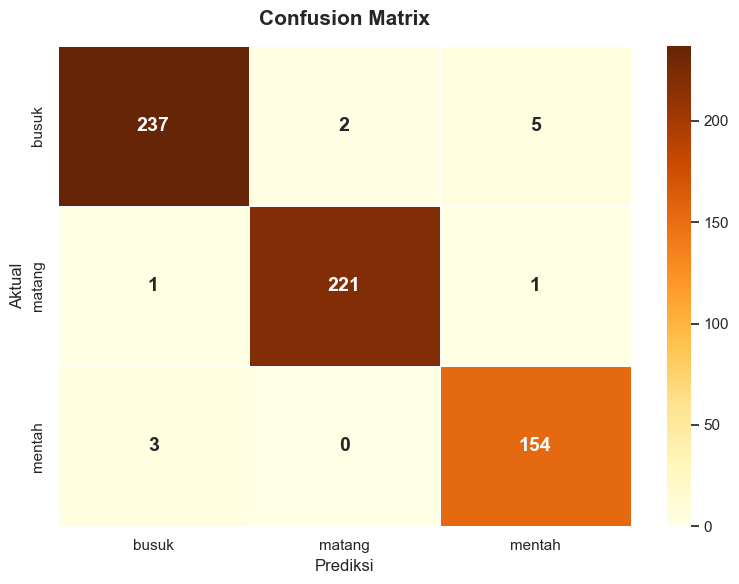

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='YlOrBr',
    xticklabels=encoder.classes_, yticklabels=encoder.classes_,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title('Confusion Matrix', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.show()

## 14. Visualisasi Performa Cross-Validation per K

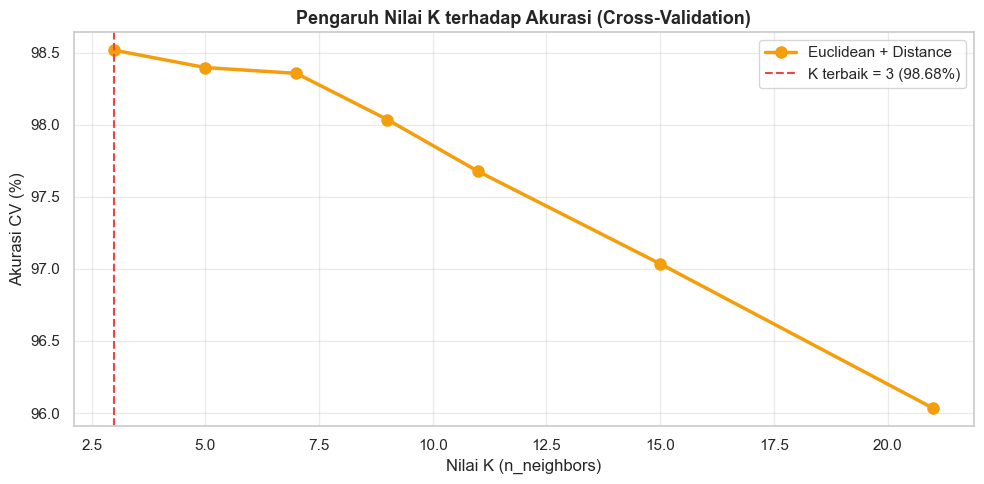

In [14]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)
results_subset = results[
    (results['param_metric'] == 'euclidean') & (results['param_weights'] == 'distance')
].copy()
results_subset = results_subset.sort_values('param_n_neighbors')

plt.figure(figsize=(10, 5))
plt.plot(
    results_subset['param_n_neighbors'],
    results_subset['mean_test_score'] * 100,
    marker='o', linewidth=2.5, color='#f59e0b', markersize=8, label='Euclidean + Distance'
)
best_k = grid.best_params_['n_neighbors']
best_acc = grid.best_score_ * 100
plt.axvline(x=best_k, color='#ef4444', linestyle='--', label=f'K terbaik = {best_k} ({best_acc:.2f}%)')
plt.xlabel('Nilai K (n_neighbors)', fontsize=12)
plt.ylabel('Akurasi CV (%)', fontsize=12)
plt.title('Pengaruh Nilai K terhadap Akurasi (Cross-Validation)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 15. Simpan Model

In [15]:
os.makedirs('../model', exist_ok=True)
joblib.dump(best_knn, '../model/banana_knn.pkl')
joblib.dump(scaler,   '../model/scaler.pkl')
joblib.dump(pca,      '../model/pca.pkl')
joblib.dump(encoder,  '../model/encoder.pkl')

print('Model berhasil disimpan ke folder model/')
print(f'  - banana_knn.pkl  (K={best_knn.n_neighbors}, metric={best_knn.metric}, weights={best_knn.weights})')
print(f'  - scaler.pkl')
print(f'  - pca.pkl  (komponen: {X_train_p.shape[1]})')
print(f'  - encoder.pkl  (kelas: {list(encoder.classes_)})')

Model berhasil disimpan ke folder model/
  - banana_knn.pkl  (K=3, metric=manhattan, weights=distance)
  - scaler.pkl
  - pca.pkl  (komponen: 41)
  - encoder.pkl  (kelas: [np.str_('busuk'), np.str_('matang'), np.str_('mentah')])
